# Notebook interactive_map

This notebook generates two static maps and one interactive point map which show wildfire locations by size class across Canada.

### Input data
- wildfire_14_18.csv: Wildfire data for the year 2014 - 2018 including a column with size
- wildfire_19_23.csv: Wildfire data for the year 2019 - 2023 including a column with size
- canada_4326.gpkg: Provinces and Territories of Canada data with crs EPSG:4326

### Outputs
- interactive_map.html: Interactive point map of Canada showing the wildfire distribution and size for 2014 - 2018 and 2019 - 2023

**Optional outputs:**
- static_map_2014_2018.png: Static point map of Canada showing the wildfire distribution and sizes for 2014 - 2018
- static_map_2019_2023.png: Static point map of Canada showing the wildfire distribution and sizes for 2019 - 2023

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# For interactive map
import folium

In [2]:
# 1. Loading data
# Loading the two wildfire datasets for they time periods 2014 - 2018 and 2019 - 2023
map_14_18 = pd.read_csv("../data/processed/wildfire_map/wildfire_14_18.csv", sep = ",")
map_19_23 = pd.read_csv("../data/processed/wildfire_map/wildfire_19_23.csv", sep = ",")
print("Data loaded successfully")

# Load Canada data
canada = gpd.read_file("../data/processed/canada_4326.gpkg")
print("Zip loaded successfully")

# Check which crs the Canada data has
print(canada.crs)

Data loaded successfully
Zip loaded successfully
EPSG:4326


## Static wildfire maps

Teh section 2. and 4. produce GeoDataFrames which are later used for the static wildfire maps (section 3. and 5.) and the interactive point map (section 6.)

The section 3. and 5. generate static wilfire maps showing the distribution of the wildfires in Canada for the time periods 2014 -2018 and 2019 - 2023.
The points are coloured in their respective size class. Only the size classes Small, Medium, Large and Extremely Large are represented.
The size class Very Small is not represented, as the huge amount of points would cover up all other points.

The section 3. and 5. are optional, as later an interactive point map is generated, showing the wildfire distributions with more information.

In [3]:
# 2. Making GeoDataFrame for wildfire data 2014 - 2018
# Generate points
geometry_14_18 = gpd.points_from_xy(
    map_14_18["longitude"],
    map_14_18["latitude"]
)

# GeoDataFrame
map_14_18_gdf = gpd.GeoDataFrame(
    map_14_18,
    geometry=geometry_14_18,
    crs="EPSG:4326"
)

# Check crs
map_14_18_gdf.crs == canada.crs

True

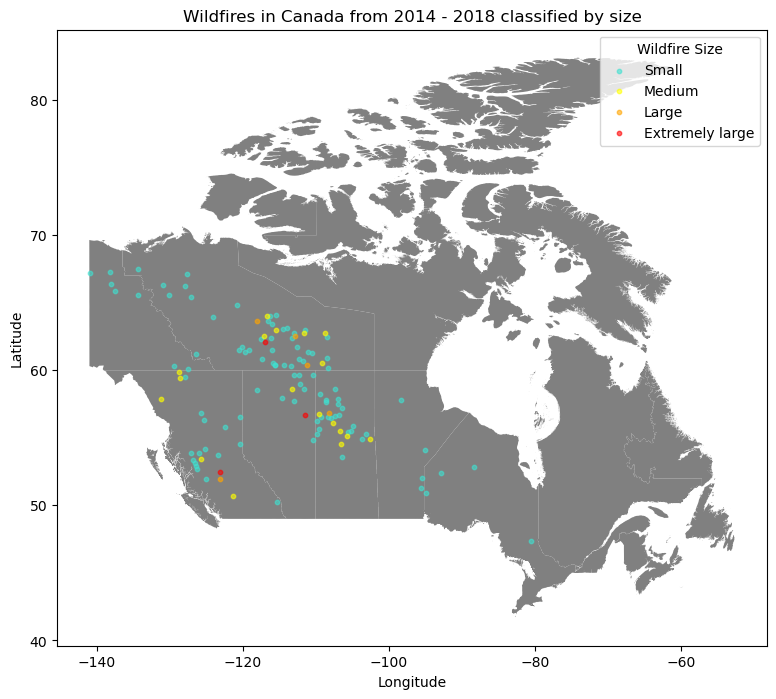

In [4]:
"""
# 3. Static wildfire map 2014 - 2018
fig, ax = plt.subplots(figsize=(10, 8))

# 3.1 Plot the GeoDataFrame directly onto specific axes
canada.plot(ax=ax, color="grey")

# 3.2 Define colors
colors = {"Small":"turquoise",
          "Medium":"yellow",
          "Large":"orange",
          "Extremely large":"red"       
}

# 3.3 Plot each class seperatly
for category, color in colors.items():

    subset = map_14_18_gdf[
        map_14_18_gdf["size"] == category
    ]

    subset.plot(
        ax=ax,
        color=color,
        markersize=10,
        alpha=0.6,
        label=category
    )

# 3.4 Legend
ax.legend(title="Wildfire Size")

# 3.5 Axes and title name
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Wildfires in Canada from 2014 - 2018 classified by size")

# 3.6 Save figure
plt.savefig("../outputs/static_map_2014_2018.png")

plt.show()
"""

In [5]:
# 4. Making GeoDataFrame for wildfire data 2019 - 2023
# Generate points
geometry_19_23 = gpd.points_from_xy(
    map_19_23["longitude"],
    map_19_23["latitude"]
)

# GeoDataFrame
map_19_23_gdf = gpd.GeoDataFrame(
    map_19_23,
    geometry=geometry_19_23,
    crs="EPSG:4326"
)

# check crs
map_19_23_gdf.crs == canada.crs

True

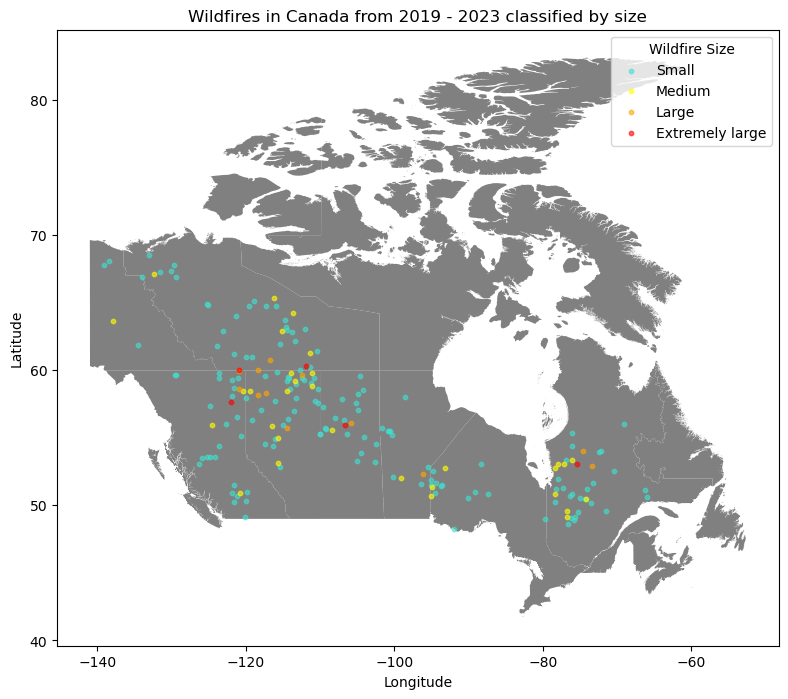

In [6]:
"""
# 5. Static wildfire map 2019 - 2023
fig, ax = plt.subplots(figsize=(10, 8))

# 5.1 Plot the GeoDataFrame directly onto specific Axes
canada.plot(ax=ax, color="grey")

# 5.2 Define colors
colors = {"Small":"turquoise",
          "Medium":"yellow",
          "Large":"orange",
          "Extremely large":"red"       
}

# 5.3 Plot each class seperatly
for category, color in colors.items():

    subset = map_19_23_gdf[
        map_19_23_gdf["size"] == category
    ]

    subset.plot(
        ax=ax,
        color=color,
        markersize=10,
        alpha=0.6,
        label=category
    )

# 5.4 Legend
ax.legend(title="Wildfire Size")

# 5.5 Axes and title name
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Wildfires in Canada from 2019 - 2023 classified by size")

# 5.6 Save figure
plt.savefig("../outputs/static_map_2019_2023.png")

plt.show()
"""

### Interactive point map

The section 6 will generate one of the main outputs of this project an interactive point map.
The map shows the distribution of the wildfires in Canada for the time periods 2014 - 2018 and 2019 - 2023.
The map consists of four layers, two for 2014 - 2018 and two for 2019 - 2023.
For each year ther is one layer with the very small wildfires and one layer with the other size classes (small, medium, large, extremely large). That ensures that no wildfires are covered by the huge amount of very small wildfires.
The points are coloured in their respective size class and additional information for each fire including the province name, the fire id, the starting year, the case and the size in hectare is given through tooltips.

In [8]:
# 6. Interactive Map which displays each fire colored in the size class
# 6.1 Using the basemap Jawg.Sunny from Jawaglab
tile_url = "https://tile.jawg.io/jawg-sunny/{z}/{x}/{y}.png?access-token=tniPiJQZVj5mGbfqOx8aIkfbRAIb4oLMomGVDcYNw07EFi13vUfu7z5GRFLN6Al9"

attribution = ('<a href="https://jawg.io" title="Tiles Courtesy of Jawg Maps" target="_blank">&copy; <b>Jawg</b>Maps</a> &copy;<a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors'
)

# 6.2 Create Folium map object
interactive_map = folium.Map(
    location=[62, -98],
    zoom_start=4,
    tiles=None
)

# 6.3 Basemap with better name
folium.TileLayer(tiles=tile_url,
                 attr=attribution,
                 name="Basemap sunny"
).add_to(interactive_map)

# 6.4 Colors
def get_colors_size(size):
    
    """
    Returns a color corresponding to a wildfire size category.

    Parameters
    ----------
    size : str
        Wildfire size category.

    Returns
    -------
    str
        Color name used for Folium markers.
    """

    colors_size = {
        "Very small": "blue",
        "Small": "turquoise",
        "Medium": "yellow",
        "Large": "orange",
        "Extremely large": "red"
    }

    return colors_size.get(size, "gray")

# 6.5 Create layers
# Layers for 2014-2018
map_14_18_other = folium.FeatureGroup(
    name= "2014 - 2018: Small - Extremely Large Wildfires",
    show=True
)

map_14_18_very_small = folium.FeatureGroup(
    name="2014 - 2018: Very Small Wildfires",
    show=False
)

# Layer for 2019-2023
map_19_23_other = folium.FeatureGroup(
    name="2019 - 2023: Small - Extremely Large Wildfires",
    show=True
)

map_19_23_very_small = folium.FeatureGroup(
    name="2019 - 2023: Very Small Wildfires",
    show=False
)

# 6.6 Create points (with tooltip and color) and add them to the layers
def add_wildfire_points(wildfire_gdf, very_small, other):
    """
    Adds wildfire point markers to Folium feature groups.

    Parameters
    ----------
    wildfire_gdf : geopandas.GeoDataFrame
        GeoDataFrame containing wildfire records and point geometries.
    very_small : folium.FeatureGroup
        Layer for very small wildfires.
    other : folium.FeatureGroup
        Layer for all other wildfire size categories (Small to Extremly Large).
   
    Returns
    -------
    None
    """

    for _, row in wildfire_gdf.iterrows():

        size = str(row["size"]).strip()

        marker=folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=5,
            color=get_colors_size(size),
            fill=True,
            fill_color=get_colors_size(size),
            fill_opacity=0.9,
            weight=1,
            tooltip=(
                f"Province: {row['province']}<br>"
                f"Fire ID: {row['fire_id']}<br>"
                f"Starting Year: {row['year']}<br>"
                f"Cause: {row['cause']}<br>"
                f"Size [ha]: {row['size_ha']}<br>"
            )
        )

        if size =="Very small":
            marker.add_to(very_small)

        else:
            marker.add_to(other)

# Making points out of the data
# For 2014-2018
add_wildfire_points(
    map_14_18_gdf,
    map_14_18_very_small,
    map_14_18_other,
)

# For 2019-2023
add_wildfire_points(
    map_19_23_gdf,
    map_19_23_very_small,
    map_19_23_other,
   )

# Add finished layers to map
map_14_18_very_small.add_to(interactive_map)
map_14_18_other.add_to(interactive_map)

map_19_23_very_small.add_to(interactive_map)
map_19_23_other.add_to(interactive_map)

# Add Layer Control
folium.LayerControl().add_to(interactive_map)

# Legend
legend_html = """
<div style="
    position: fixed;
    bottom: 50px;
    left: 50px;
    width: 150px;
    background-color: white;
    border:1px solid grey;
    z-index:9999;
    font-size:14px;
    padding: 12px;
">

<b>Wildfire Size</b><br><br>

<div><span style="color:blue;">⬤</span> Very Small</div>
<div><span style="color:cyan;">⬤</span> Small</div>
<div><span style="color:gold;">⬤</span> Medium</div>
<div><span style="color:orange;">⬤</span> Large</div>
<div><span style="color:red;">⬤</span> Extremely Large</div>

</div>
"""
interactive_map.get_root().html.add_child(folium.Element(legend_html))

# Save interactive map
interactive_map.save("../outputs/interactive_map.html")

interactive_map

**Interpretation:**

As can be seen in the map above there are more fires in the size class small, medium, large and extremely large in the time period 2019 - 2023 than in the time period 2014 -2018.
Another important aspect is that fires in 2019 – 2023 are now also in locations which had no fires in 2014 – 2018.